# House Price Prediction System

# Model Evaluation

## Objectives

- Evaluate the best-performing regression model
- Calculate regression evaluation metrics
- Understand model performance

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import numpy as np

## Load Dataset

In [2]:
df = pd.read_csv("../data/Housing.csv")

In [3]:
yes_no_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in yes_no_columns:
    df[col] = df[col].map({
        "yes":1,
        "no":0
    })

df["furnishingstatus"] = df["furnishingstatus"].map({
    "furnished":2,
    "semi-furnished":1,
    "unfurnished":0
})

In [4]:
X = df.drop("price", axis=1)

y = df["price"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

## Mean Absolute Error (MAE)

In [7]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error :", round(mae,2))

Mean Absolute Error : 1024081.03


## Mean Squared Error (MSE)

In [8]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error :", round(mse,2))

Mean Squared Error : 1956925181711.52


## Root Mean Squared Error (RMSE)

In [9]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error :", round(rmse,2))

Root Mean Squared Error : 1398901.42


## R² Score

In [10]:
r2 = r2_score(y_test, predictions)

print("R² Score :", round(r2,4))

R² Score : 0.6128


## Actual vs Predicted Values

In [11]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

results.head(10)

,Actual Price,Predicted Price
0,4060000,5309430.00
1,6650000,7435750.00
2,3710000,3769578.75
3,6440000,4465300.00
4,2800000,3734850.00
5,4900000,3524920.00
6,5250000,5025370.00
7,4543000,5222350.00
8,2450000,2560320.00
9,3353000,2868789.00


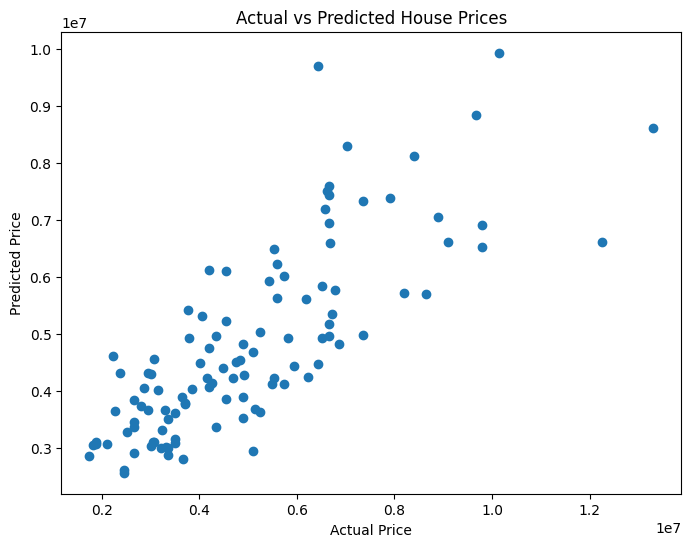

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

# Evaluation Summary

### Metrics Used

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The Random Forest Regressor performed well and is selected for deployment.